# Supplementary Tables: Model Hyperparameters

In [1]:
import matplotlib.pyplot as plt
import EIANN as eiann
import EIANN.utils as ut
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()
model_dict_all = load_model_dict()

import nbimporter
from Supplementary_Accuracy_Tables import latex_to_unicode

%load_ext autoreload
%autoreload 2

In [23]:
def generate_hyperparams_csv(model_dict_all, model_list, filename):
    root_dir = ut.get_project_root()
    hyperparams_dict = {}

    for model_key in model_list:
        config_file = model_dict_all[model_key]['config']

        # build path to config YAML
        base = os.path.join(root_dir, 'EIANN', 'network_config')    
        if 'mnist' in config_file and 'spiral' not in config_file:
            base = os.path.join(base, 'mnist')
        elif 'spiral' in config_file:
            base = os.path.join(base, 'spiral')
        cfg_path = os.path.join(base, config_file)

        label = model_dict_all[model_key]['display_name']
        model_cfg = ut.read_from_yaml(cfg_path)
        proj_cfg = model_cfg.get('projection_config', {})
        hyperparams_dict[label] = flatten_projection_config(proj_cfg)

    df = pd.DataFrame.from_dict(hyperparams_dict)
    hyperparam_names = []
    abbreviated_names = []
    for param_name in df.index:
        abbreviation = shorten_label(param_name)
        hyperparam_names.append(param_name)
        abbreviated_names.append(abbreviation)
    df.insert(0, 'Param name', abbreviated_names)
    df = df.fillna("-")

    out_file = f"{root_dir}/EIANN/data/{filename}.csv"
    df.to_csv(out_file, index=False)
    print(f"Saved hyperparams table to /EIANN/EIANN/data/{filename}.csv")

In [2]:
def generate_hyperparams_table(csv_filename):
    # Load model specs from csv file
    root_dir = ut.get_project_root()
    csv_path = f"{root_dir}/EIANN/data/{csv_filename}.csv"
    df = pd.read_csv(csv_path)

    num_columns = len(df.columns)
    num_rows = len(df)

    fig_width = num_columns*0.85
    fig_height = num_rows*0.23
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    if fig_width > 8.5:
        print(f"WARNING: Table too wide ({fig_width} inch) to fit on one page. Consider reducing the number of columns.")
    if fig_height > 11:
        print(f"WARNING: Table too tall ({fig_height} inch) to fit on one page. Consider reducing the number of rows.")
    # fig, ax = plt.subplots(figsize=(5.5, 9))
    ax.axis('off')

    def round_if_numeric(x, decimals):
        try:
            f = float(x)
            return f"{f:.{decimals}f}"
        except (ValueError, TypeError):
            return x
    df = df.map(round_if_numeric, decimals=4)

    col_widths = [1/(0.83*num_columns)] * num_columns
    col_widths[0] *= 1.2
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc="center", loc="center", colWidths=col_widths)
    table.auto_set_font_size(False)    
    for key, cell in table.get_celld().items():
        cell.set_linewidth(0)
        cell.set_height(cell.get_height() * 1.3)
        cell.set_text_props(fontname='Arial', fontsize=6)
        if key[0] == 0: # Header row
            cell.set_facecolor([0.9 for i in range(3)])
            cell.set_text_props(weight='bold')
            cell.set_height(cell.get_height() * 1.2)
        elif key[0] % 2 == 0: # Even rows
            cell.set_facecolor([0.96 for i in range(3)]) # make even rows light grey

        if key[1] == 0: # First column
            cell.set_text_props(horizontalalignment='left')
            # cell.set_width(cell.get_width() * 1.5)
            
    fig.savefig(f"{root_dir}/EIANN/figures/{csv_filename}.png", dpi=300)
    fig.savefig(f"{root_dir}/EIANN/figures/{csv_filename}.svg", dpi=300)

In [11]:
csv_filename = "FigT6_mnist_hyperparams"



# def export_hyperparams_table(csv_filename):

# Load model specs from csv file
root_dir = ut.get_project_root()
csv_path = f"{root_dir}/EIANN/data/{csv_filename}.csv"
df = pd.read_csv(csv_path)


# Convert text in 'Param name' column to Unicode
df['Param name'] = df['Param name'].apply(lambda x: latex_to_unicode(x))

df.head(30)

# column_labels = list(columns.keys()) + new_column_labels
# column_labels[0] = ""

# # Create Excel file with pandas DataFrame (with LaTeX converted to Unicode)
# # Convert all table values to unicode
# table_vals_unicode = [[latex_to_unicode(val) for val in row] for row in table_vals]
# column_labels_unicode = [latex_to_unicode(col) for col in column_labels]

# # Create DataFrame and export to Excel
# df = pd.DataFrame(table_vals_unicode, columns=column_labels_unicode)

# # Export to Excel - unicode characters will be preserved automatically
# excel_path = f"{root_dir}/EIANN/figures/{figure_name}.xlsx"
# df.to_excel(excel_path, index=False, sheet_name='Summary')



,Param name,Feedforward ANN,Feedforward ANN \n(fixed hidden),Feedforward ANN \n(no hidden),Backprop \n(fixed SomaI),Backprop \n(learned SomaI),Backprop \n(no SomaI),Hebbian,Fixed DendI \n(random),Learned DendI \n(local backprop),Dendritic \nTarget Propagation,Temporally \nContrastive Hebb,BCM,BTSP,"LDS, \nfixed top-down","LDS, \nlearned top-down","BTSP, \nfixed top-down","BTSP, \nlearned top-down"
0,W\ₘₐₜₕᵣₘ{ᵢₙᵢₜ} (H1),2.957309048541877,5.011995913830346,-,2.416858991797159,2.3417824834756154,0.03126589111604868,-,0.4806521598092204,1.7766722560842219,2.1944449483442714,0.6845279237773562,1.5777526066284728,3.5237432323905913,1.5073013034533822,1.334544098018755,3.9820546761226923,3.61727120337632
1,"\eta, W (H1)",0.1652392249674756,-,-,0.3980860680942911,0.39131108185597463,0.190425996980815,0.005530094753086432,0.0024363890299705193,0.0055029265858721485,0.014965181204220036,0.035702665026798856,0.005276417437133462,0.010099382350939995,0.01710810722072439,0.017757944704534304,0.002499955095692264,0.008046168178811415
2,W\ₘₐₜₕᵣₘ{ᵢₙᵢₜ} (H2),0.30688143784094596,0.32719946303255487,-,0.5427969492492737,0.7159217705891364,1.4197298419217201,-,1.3194771689032636,1.8245419018635485,0.19699100861932295,0.1834434279478901,0.04060862080020256,0.8324299842972416,1.326063290959874,0.7726457666473203,1.3293719349123683,1.8581047840696694
3,"\eta, W (H2)",0.1652392249674756,-,-,0.3980860680942911,0.39131108185597463,0.190425996980815,0.005530094753086432,0.0024363890299705193,0.0055029265858721485,0.014965181204220036,0.035702665026798856,0.005276417437133462,0.010099382350939995,0.01710810722072439,0.017757944704534304,0.002499955095692264,0.008046168178811415
4,W\ₘₐₜₕᵣₘ{ᵢₙᵢₜ} (Output),2.093606302139006,0.020279061698152266,0.0264769781294784,3.281687708158219,1.0173247817366127,3.9650112451759414,1.1091168830399416,2.6245445247620682,0.3040695673093695,5.574051454118832,3.8974313191674868,1.7048958127146772,8.597381937643748,0.43225835920438016,1.3278406847942748,12.641019004421423,12.951974755630944
5,"\eta, W (Output)",0.02168234235499228,0.058201439241708425,0.004068166395236531,0.07078468081982983,0.3264900426693538,0.011046295251110779,0.01925228325960693,0.011049873024226116,0.0008175707829444737,0.025823599084628956,0.0027399144722221234,0.0020699706260033693,0.02582435747972173,0.022184111740388156,0.016212839237083457,0.0290885208879536,0.027374269276855868
6,"Y\ₘₐₜₕᵣₘ{ᵢₙᵢₜ} (SomaI, H1)",-,-,-,1.1158572938882887,1.533181728235414,-,-,1.3258763794329849,1.135382498866865,1.127575300929014,0.5709081436842554,0.7547901746981226,2.196024886031613,0.7135693808213259,1.1994926797054999,0.9457871075285322,0.9531247877367462
7,"W\ₘₐₜₕᵣₘ{ᵢₙᵢₜ} (SomaI, H1)",-,-,-,3.1371037827062644,2.0285876282656115,-,-,0.5831838036593324,1.9747147182132987,2.9554092309918674,0.6061836398422455,1.5437059260660204,2.2087109611429696,2.8737536423658696,0.9968362476919066,3.64308664636432,2.9392482171947822
8,"Q\ₘₐₜₕᵣₘ{ᵢₙᵢₜ} (SomaI, H1)",-,-,-,0.4835575833031128,0.3539605385732712,-,-,0.4593417946538286,0.31603985401748097,0.7922286649101926,0.2994070569953245,0.9798467535193344,0.7035747473578501,0.8390095918853383,0.34488602131546225,0.33864327471858513,0.3795650168540203
9,"R\ₘₐₜₕᵣₘ{ᵢₙᵢₜ} (SomaI, H1)",-,-,-,1.295863932103535,1.2781263390521735,-,-,1.1411798121204462,1.0788916312761898,1.4659723687430724,0.3529658821313441,0.5321690501979497,1.1847761465963123,1.2690055908271352,0.8168111262978619,0.8937830285936182,0.8944540089568928


In [4]:
df['Param name']

0         W$_{\mathrm{init}}$ (H1)
1                   $\eta$, W (H1)
2         W$_{\mathrm{init}}$ (H2)
3                   $\eta$, W (H2)
4     W$_{\mathrm{init}}$ (Output)
                  ...             
75        B$_{\mathrm{init}}$ (H2)
76                  $\eta$, B (H1)
77         B$_{\mathrm{sum}}$ (H1)
78                  $\eta$, B (H2)
79         B$_{\mathrm{sum}}$ (H2)
Name: Param name, Length: 80, dtype: object

# MNIST Hyperparams

In [ ]:
model_list = ["vanBP", "vanBP_fixed_hidden", "vanBP_0hidden", "bpDale_fixed", "bpDale_learned", "bpDale_noI", "HebbWN_topsup",
                "bpLike_WT_fixedDend", "bpLike_WT_localBP", "bpLike_WT_hebbdend", "SupHebbTempCont_WT_hebbdend", "Supervised_BCM_WT_hebbdend",
                "BTSP_WT_hebbdend", "bpLike_fixedTD_hebbdend", "bpLike_TCWN_hebbdend", "BTSP_fixedTD_hebbdend", "BTSP_TCWN_hebbdend"]

filename = "FigT6_mnist_hyperparams"
generate_hyperparams_csv(model_dict_all, model_list, filename=filename)

Saved hyperparams table to /EIANN/EIANN/data/FigT6_mnist_hyperparams.csv


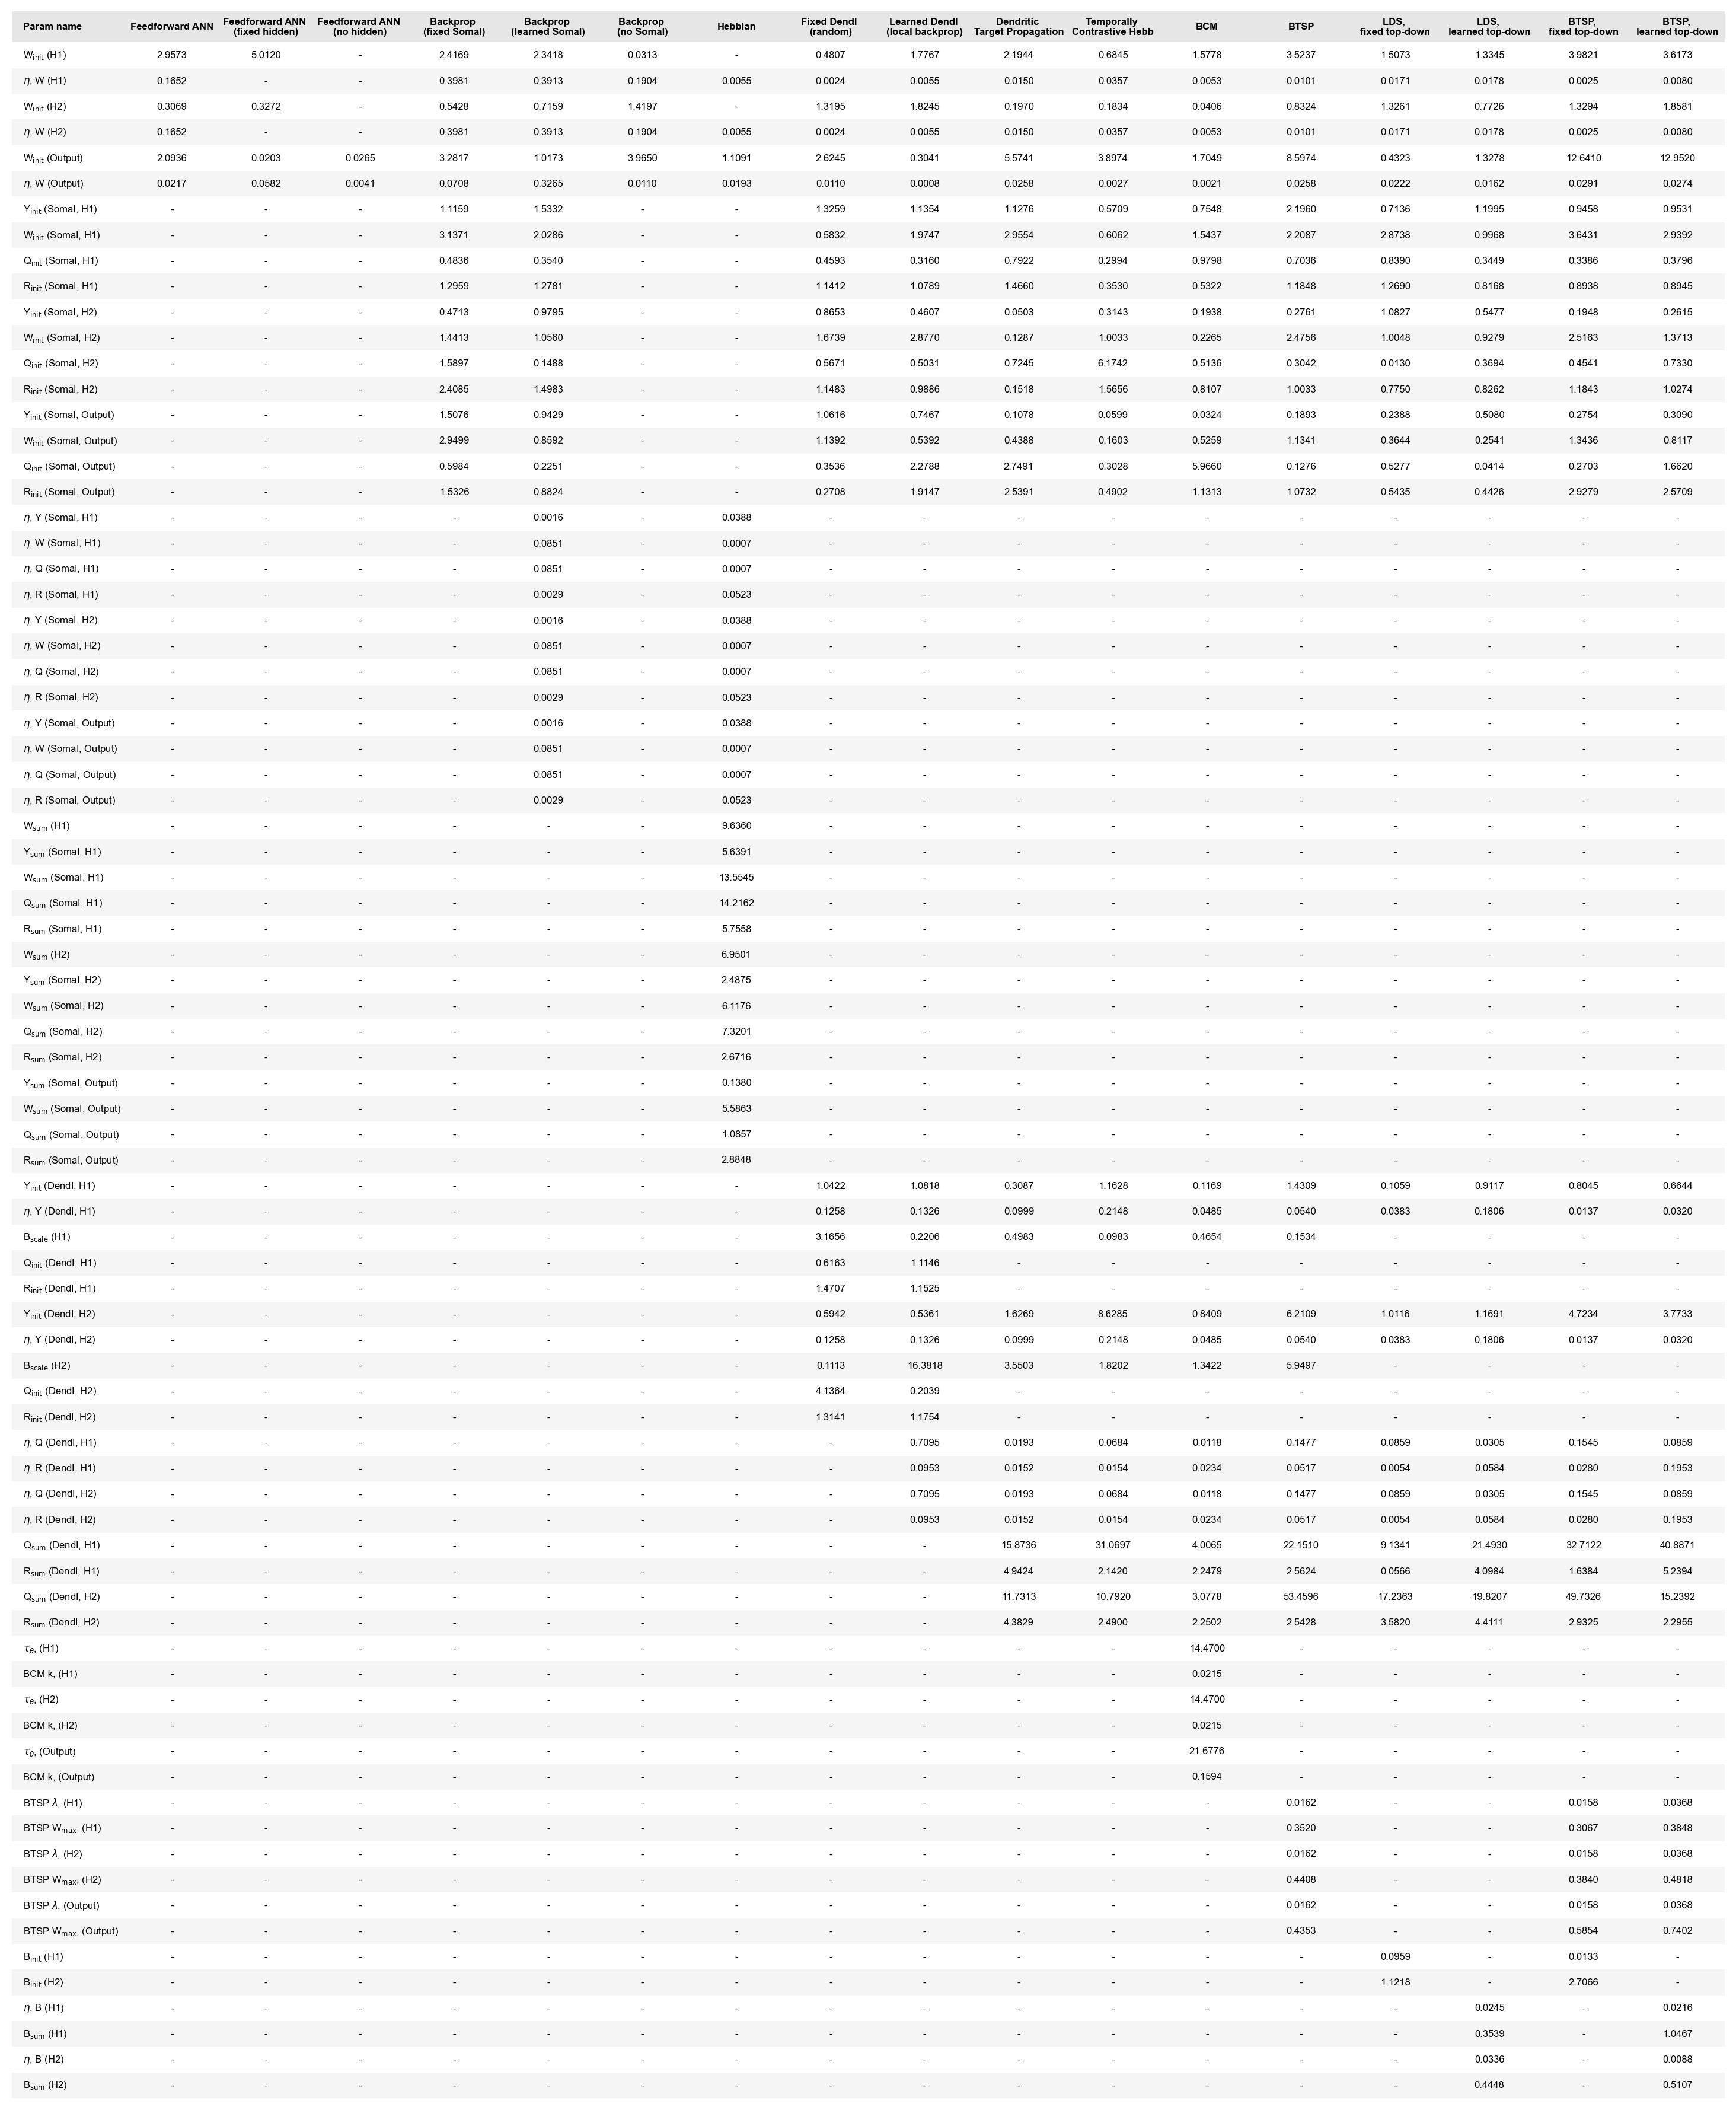

In [54]:
csv_filename = "FigT6_mnist_hyperparams"
generate_hyperparams_table(csv_filename)

# Spirals Hyperparams